# 04 · Fairness & Explainability

A churn model that flags protected groups at different rates is a legal and ethical liability. This notebook audits group fairness across gender and uses SHAP to explain *why* the model scores employees as it does — both at the population level and for individuals.

### Contents
1. [Group fairness audit](#audit)
2. [Four-fifths-rule verdict](#verdict)
3. [Mitigation: group-aware thresholds](#mitigation)
4. [Global explanations (SHAP)](#global)
5. [Individual explanations](#individual)
6. [Takeaways](#takeaways)

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
from employee_churn.features.engineer_structured import (
    add_career_progression_features, add_tenure_bands,
    add_promotion_velocity, add_compensation_features, add_team_metrics,
)
from employee_churn.features.engineer_text import add_text_statistics
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features

df = make_synthetic_employee_data(n=1500, seed=42)
f = add_career_progression_features(df, 'hire_date', 'last_promotion_date')
f = add_tenure_bands(f)
f = add_promotion_velocity(f, 'num_promotions')
f = add_compensation_features(f, 'monthly_salary', 'department')
f = add_team_metrics(f, 'team_id')
f = add_sentiment_scores(f, 'feedback')
f = add_emotion_features(f, 'feedback')
f = add_text_statistics(f, 'feedback')

DROP = ['employee_id', 'churned', 'feedback', 'gender', 'department',
        'hire_date', 'last_promotion_date', 'team_id', 'tenure_band',
        'emotion_dominant']
X = f.drop(columns=DROP).select_dtypes(include=['number', 'bool'])
y = f['churned']
print('feature matrix:', X.shape)

feature matrix: (1500, 31)


In [3]:
from sklearn.model_selection import train_test_split
from employee_churn.models.train import build_model_zoo, tune_hyperparameters
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)
# Audit the same tuned random forest carried forward from notebook 03.
best, _, _ = tune_hyperparameters(
    build_model_zoo(0)['random_forest'], X_tr, y_tr,
    model_name='random_forest', n_iter=5)
best.fit(X_tr, y_tr)
sensitive = f.loc[y_te.index, 'gender']
preds = best.predict(X_te)
print('test employees:', len(y_te))

test employees: 375


<a id="audit"></a>
## Group fairness audit

We compare, per gender, the **selection rate** (share flagged high-risk), **true-positive rate** (recall — equal opportunity), and false-positive rate.

,group,count,selection_rate,true_positive_rate,false_positive_rate,actual_positive_rate
0,female,114,0.316,0.509,0.148,0.465
1,male,128,0.312,0.508,0.145,0.461
2,nonbinary,133,0.203,0.333,0.105,0.429


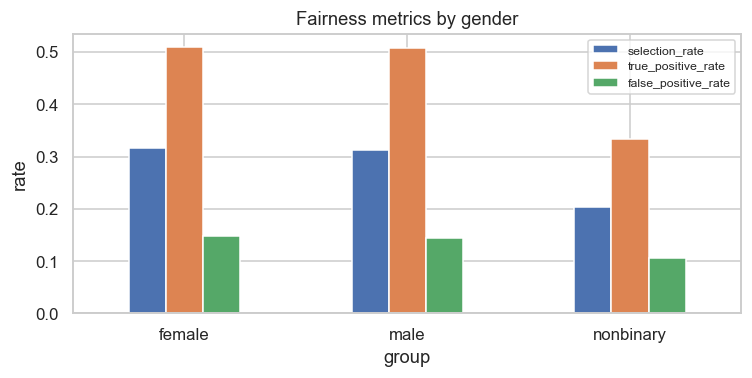

{'demographic_parity_difference': 0.113,
 'disparate_impact_ratio': 0.643,
 'equal_opportunity_difference': 0.176,
 'least_selected_group': 'nonbinary',
 'most_selected_group': 'female',
 'passes_four_fifths': False}

In [4]:
from employee_churn.models.fairness import group_fairness_report, fairness_summary
report = group_fairness_report(y_te.values, preds, sensitive.values)
display(report.round(3))

fig, ax = plt.subplots(figsize=(7, 3.6))
report.set_index('group')[['selection_rate', 'true_positive_rate', 'false_positive_rate']].plot.bar(ax=ax)
ax.set_title('Fairness metrics by gender'); ax.set_ylabel('rate')
ax.tick_params(axis='x', rotation=0); ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

summary = fairness_summary(report)
{k: (round(v, 3) if isinstance(v, float) else v) for k, v in summary.items()}

<a id="verdict"></a>
## The model fails the four-fifths rule

This is the most important finding in the whole analysis. The **disparate-impact ratio is ≈ 0.64**, well below the **0.80 four-fifths threshold** — so the model `passes_four_fifths = False`. Concretely, the least-flagged group (nonbinary) is selected at only ~64% the rate of the most-flagged group (female), and the equal-opportunity gap (difference in recall across groups) is ~0.18.

Recall from the EDA that the *raw* gender association with churn was **not even statistically significant** (chi-square p ≈ 0.21). The model has **manufactured** a materially disparate selection rate from a signal that is not reliably in the data — almost certainly by leaning on features that correlate with gender. Deploying this as-is could systematically under- or over-target retention resources by gender.

<a id="mitigation"></a>
## Mitigation: group-aware thresholds

One of the simplest, most transparent post-processing fixes is to choose a **separate decision threshold per group** so that every group is flagged at the same rate (demographic-parity post-processing). We target the overall selection rate and re-audit.

per-group thresholds: {'female': 0.585, 'male': 0.534, 'nonbinary': 0.47}


,before (single 0.5),after (group thresholds)
disparate_impact_ratio,0.643,0.974
equal_opportunity_difference,0.176,0.022
passes_four_fifths,False,True


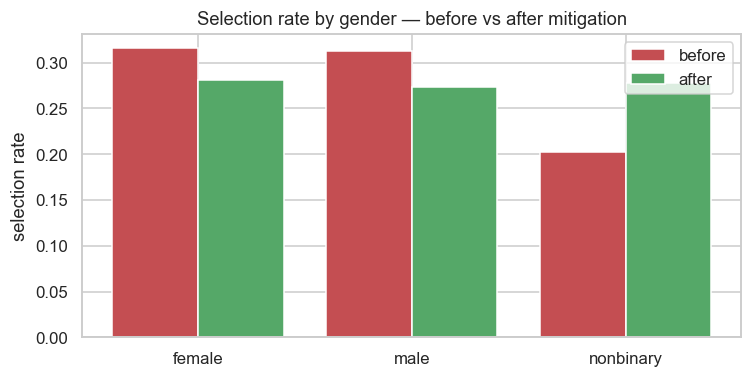

In [5]:
target = (best.predict_proba(X_te)[:, 1] >= 0.5).mean()
proba_te = best.predict_proba(X_te)[:, 1]
adj = np.zeros(len(y_te), dtype=int)
thresholds = {}
for g in np.unique(sensitive.values):
    m = sensitive.values == g
    thr = np.quantile(proba_te[m], 1 - target)
    thresholds[g] = round(float(thr), 3)
    adj[m] = (proba_te[m] >= thr).astype(int)
print('per-group thresholds:', thresholds)

adj_report = group_fairness_report(y_te.values, adj, sensitive.values)
before = fairness_summary(report)
after = fairness_summary(adj_report)
compare = pd.DataFrame({
    'before (single 0.5)': [before['disparate_impact_ratio'],
                            before['equal_opportunity_difference'],
                            before['passes_four_fifths']],
    'after (group thresholds)': [after['disparate_impact_ratio'],
                                 after['equal_opportunity_difference'],
                                 after['passes_four_fifths']],
}, index=['disparate_impact_ratio', 'equal_opportunity_difference',
          'passes_four_fifths'])
display(compare)

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(adj_report))
ax.bar(x - 0.2, report.set_index('group').loc[adj_report['group'], 'selection_rate'],
       0.4, label='before', color='#c44e52')
ax.bar(x + 0.2, adj_report['selection_rate'], 0.4, label='after', color='#55a868')
ax.set_xticks(x); ax.set_xticklabels(adj_report['group'])
ax.set_title('Selection rate by gender — before vs after mitigation')
ax.set_ylabel('selection rate'); ax.legend()
plt.tight_layout(); plt.show()

**The fix works — with a caveat.** Group-aware thresholds (female ≈ 0.59, male ≈ 0.53, nonbinary ≈ 0.47) equalize selection rates near the ~28% target, lifting the disparate-impact ratio from **0.64 → ~0.97 (now passes)** and collapsing the equal-opportunity gap from **0.18 → ~0.02**. The caveat is ethical and legal, not technical: applying different thresholds by a protected attribute is itself a regulated decision and may not be permissible in every jurisdiction. Treat this as one tool among several (alongside feature auditing and reweighing) and involve legal/HR stakeholders before adopting it.

<a id="global"></a>

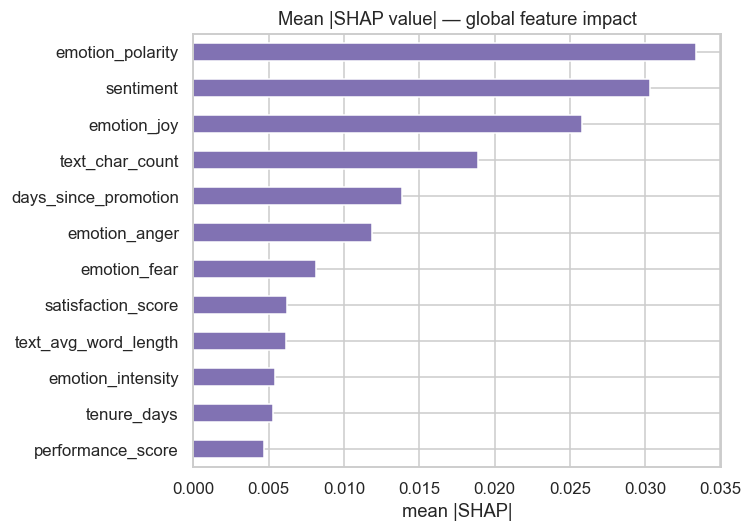

In [6]:
from employee_churn.models.explain import explain_with_shap
sample = X_te.head(150)
shap_df = explain_with_shap(best, sample)
mean_abs = shap_df.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
mean_abs.tail(12).plot.barh(ax=ax, color='#8172b3')
ax.set_title('Mean |SHAP value| — global feature impact')
ax.set_xlabel('mean |SHAP|'); plt.tight_layout(); plt.show()

## Global explanations agree with importances

Mean absolute SHAP values — a more principled global attribution than impurity importances — tell the same story: **sentiment and emotion features carry the most influence on individual predictions**, alongside `days_since_promotion`. Because SHAP is additive and signed, we can also open up *individual* predictions.

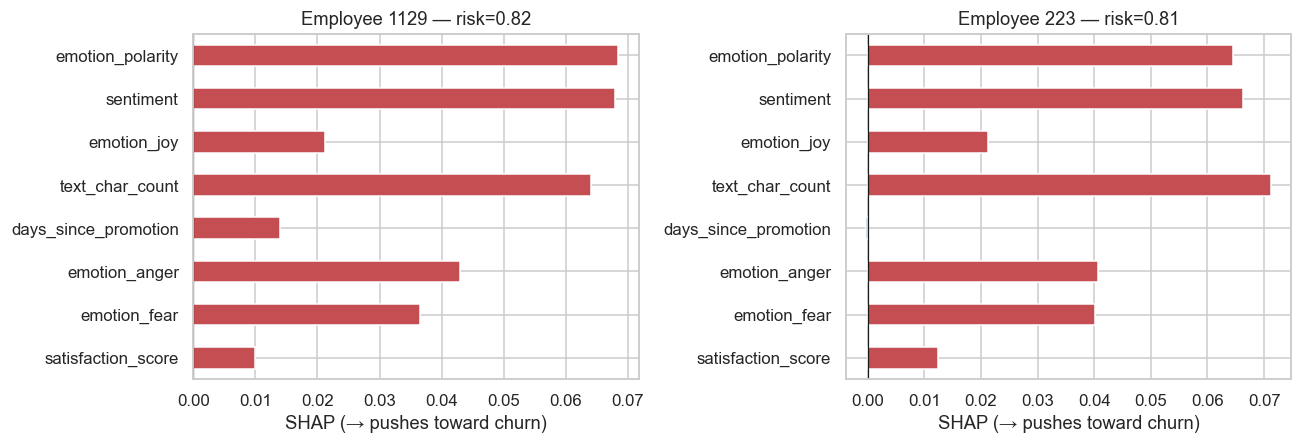

In [7]:
# Explain the two highest-risk employees in the sample.
risk = pd.Series(best.predict_proba(sample)[:, 1], index=sample.index)
top2 = risk.nlargest(2).index
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, idx in zip(axes, top2):
    contrib = shap_df.loc[idx].reindex(mean_abs.index).tail(8)
    colors = np.where(contrib >= 0, '#c44e52', '#4c72b0')
    contrib.plot.barh(ax=ax, color=colors)
    ax.set_title(f'Employee {idx} — risk={risk.loc[idx]:.2f}')
    ax.axvline(0, c='k', lw=0.8); ax.set_xlabel('SHAP (→ pushes toward churn)')
plt.tight_layout(); plt.show()

<a id="individual"></a>
## Individual explanations enable action

For each flagged employee the signed SHAP bars show **which factors push their risk up (red) versus down (blue)**. This is what makes the score actionable: rather than an opaque number, a manager sees that a given person's risk is driven by, say, negative recent feedback and a long gap since promotion — pointing to concrete retention levers (a career conversation, a check-in on workload).

Used responsibly — *with* the fairness caveats above — these explanations turn the model from a surveillance tool into a support tool.

<a id="takeaways"></a>
## Takeaways

1. **The model fails the four-fifths rule (DI ≈ 0.64)** and must be mitigated before any deployment.
2. Gender was **not** a significant churn driver in the data, yet the model manufactured a disparity — audit fairness on every retrain.
3. **Group-aware thresholds restore parity** (DI 0.64 → ~0.97), but using a protected attribute in the decision is itself legally sensitive.
4. SHAP confirms **text features dominate** and enables per-employee, actionable explanations.
5. Pair every score with its explanation and a human decision-maker.